# Taller análisis descriptivo de variables cualitativas

Se va a trabajar con un dataset que contiene información sobre incidentes de tránsito en Medellín con víctimas.

Cárguelo y verifique que se haya cargado correctamente.

In [474]:
import pandas as pd

df_accidentes = pd.read_csv("Accidentes de tránsito en Medellín.csv")

La variable "Fecha_incidente" debe convertirse a dato de tiempo.

Excluya los datos del año 2021.

In [475]:

df_accidentes["Fecha_incidente"] = pd.to_datetime(df_accidentes["Fecha_incidente"])

df_accidentes["Año"] = pd.Categorical(
    df_accidentes["Año"],
    categories = [2014, 2015, 2016, 2017, 2018, 2019, 2020],
    ordered=True,)

df_accidentes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235843 entries, 0 to 235842
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Fecha_incidente   235843 non-null  datetime64[ns]
 1   Gravedad_victima  235843 non-null  object        
 2   Clase_incidente   235843 non-null  object        
 3   Sexo              233366 non-null  object        
 4   Condicion         235843 non-null  object        
 5   Grupo_edad        233309 non-null  object        
 6   Comuna            214117 non-null  object        
 7   Barrio            213961 non-null  object        
 8   Dia_semana        235843 non-null  object        
 9   Mes               235843 non-null  object        
 10  Año               214116 non-null  category      
dtypes: category(1), datetime64[ns](1), object(9)
memory usage: 18.2+ MB


De acuerdo a lo visto en clase, indique qué tipo de variable es cada una de las que están en el DataFrame.

Convierta a "category" las variables categóricas, cuidando que las variables nominales y ordinales queden correctamente convertidas.

In [476]:
df_accidentes['Sexo'] = df_accidentes['Sexo'].astype('category')

df_accidentes['Clase_incidente'] = df_accidentes['Clase_incidente'].astype('category')

df_accidentes['Condicion'] = df_accidentes['Condicion'].astype('category')

df_accidentes['Gravedad_victima'] = df_accidentes['Gravedad_victima'].astype('category')

df_accidentes['Grupo_edad'] = df_accidentes['Grupo_edad'].astype('category')

df_accidentes['Comuna'] = df_accidentes['Comuna'].astype('category')

df_accidentes['Barrio'] = df_accidentes['Barrio'].astype('category')

df_accidentes['Dia_semana'] = df_accidentes['Dia_semana'].astype('category')

df_accidentes['Mes'] = df_accidentes['Mes'].astype('category')

df_accidentes["Dia_semana"] = pd.Categorical(
    df_accidentes["Dia_semana"],
    categories = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo",],
    ordered=True,)

df_accidentes["Mes"] = pd.Categorical(
    df_accidentes["Mes"],
    categories = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"],
    ordered=True,)

df_accidentes["Grupo_edad"] = pd.Categorical(
    df_accidentes["Grupo_edad"],
    categories = ["0 - 9", "10 - 19", "20 - 29", "30 - 39", "40 - 49", "50 - 59", "60 - 69", "70 - 79", "80 o más"],
    ordered=True,)



df_accidentes.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235843 entries, 0 to 235842
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Fecha_incidente   235843 non-null  datetime64[ns]
 1   Gravedad_victima  235843 non-null  category      
 2   Clase_incidente   235843 non-null  category      
 3   Sexo              233366 non-null  category      
 4   Condicion         235843 non-null  category      
 5   Grupo_edad        233309 non-null  category      
 6   Comuna            214117 non-null  category      
 7   Barrio            213961 non-null  category      
 8   Dia_semana        235843 non-null  category      
 9   Mes               235843 non-null  category      
 10  Año               214116 non-null  category      
dtypes: category(10), datetime64[ns](1)
memory usage: 4.3 MB


Identifique qué variable(s) tienen alta cardinalidad. Excluya esta(s) de los análisis posteriores.

In [477]:
df_accidentes = df_accidentes.drop(columns = ['Barrio'])

print(df_accidentes.nunique())

df_accidentes.info()

Fecha_incidente     2830
Gravedad_victima       2
Clase_incidente        6
Sexo                   2
Condicion              7
Grupo_edad             9
Comuna                21
Dia_semana             7
Mes                   12
Año                    7
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235843 entries, 0 to 235842
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Fecha_incidente   235843 non-null  datetime64[ns]
 1   Gravedad_victima  235843 non-null  category      
 2   Clase_incidente   235843 non-null  category      
 3   Sexo              233366 non-null  category      
 4   Condicion         235843 non-null  category      
 5   Grupo_edad        233309 non-null  category      
 6   Comuna            214117 non-null  category      
 7   Dia_semana        235843 non-null  category      
 8   Mes               235843 non-null  category      
 9   Año             

Haga las tablas de frecuencias porcentuales de todas las variables categóricas.

Para cada variable, indique cuál es la categoría más frecuente y cuál la menos frecuente.

Identifique qué variables presentan categorías atípicas. Indique los nombres de las categorías atípicas.

In [478]:
df_accidentes['Sexo'].value_counts(normalize = True, ascending=False)


,proportion
Sexo,
M,0.692487
F,0.307513


Mas frecuente = M, Menos frecuente = F

In [479]:
df_accidentes['Clase_incidente'].value_counts(normalize = True, ascending = False)

,proportion
Clase_incidente,
Choque,0.438355
Otro,0.174531
Atropello,0.167293
Caida Ocupante,0.148819
Volcamiento,0.070899
Incendio,0.000102


Mas frecuente = Choque, Menos frecuente = Incendio, Valor Atipico = Incendio

In [480]:
df_accidentes['Condicion'].value_counts(normalize = True, ascending=False)


,proportion
Condicion,
Motociclista,0.602804
Peatón,0.137358
Acompañante de Motocicleta,0.122548
Pasajero,0.057343
Acompañante de motocicleta,0.030770
Conductor,0.026259
Ciclista,0.022918


Mas frecuente = Motociclista, Menos frecuente = Ciclista

In [481]:
df_accidentes['Gravedad_victima'].value_counts(normalize = True, ascending=False)

,proportion
Gravedad_victima,
Heridos,0.991736
Muertos,0.008264


Mas frecuente = Heridos, Menos frecuente = Muertos, Valores atipico = Muertos

In [482]:
df_accidentes['Grupo_edad'].value_counts(normalize = True, ascending=False)

,proportion
Grupo_edad,
20 - 29,0.400803
30 - 39,0.214552
40 - 49,0.132502
10 - 19,0.102726
50 - 59,0.069264
60 - 69,0.031130
0 - 9,0.027281
70 - 79,0.015494
80 o más,0.006245


Mas frecuente = 20 - 29, Menos frecuente = 80 o más, Valores atipico = 80 o más

In [483]:
df_accidentes['Comuna'].value_counts(normalize = True, ascending=False)

,proportion
Comuna,
10 - La Candelaria,0.172733
05 - Castilla,0.106871
11 - Laureles Estadio,0.093043
07 - Robledo,0.077962
04 - Aranjuez,0.067879
15 - Guayabal,0.067211
16 - Belén,0.063718
14 - El Poblado,0.057188
09 - Buenos Aires,0.044051


Mas frecuente = La candelaria, Menos frecuente = corregimiento de san sebastián de Palmitas, Valor atipico = corregimiento de san sebastián de Palmitas


In [484]:
df_accidentes['Dia_semana'].value_counts(normalize = True,ascending=False)

,proportion
Dia_semana,
Miércoles,0.148039
Viernes,0.147793
Martes,0.147344
Jueves,0.146572
Sábado,0.144617
Lunes,0.144494
Domingo,0.121140


Mas frecuente = Miércoles, Menos frecuente = Domingo

In [485]:
df_accidentes['Mes'].value_counts(normalize = True,ascending=False)

,proportion
Mes,
Agosto,0.092829
Septiembre,0.092528
Julio,0.088835
Marzo,0.087177
Febrero,0.086977
Mayo,0.083314
Junio,0.083157
Enero,0.080482
Octubre,0.078506


Mas frecuente = Agosto, Menos frecuente = Noviembre

Para las variables nominales, haga un gráfico de barras horizontales de la tabla de frecuencia relativa, ordenados de forma descendente.

Para las variables ordinales, haga un gráfico de barras verticales de la tabla de frecuencia relativa, ordenados de acuerdo al orden de las categorías.

<Axes: ylabel='Gravedad_victima'>

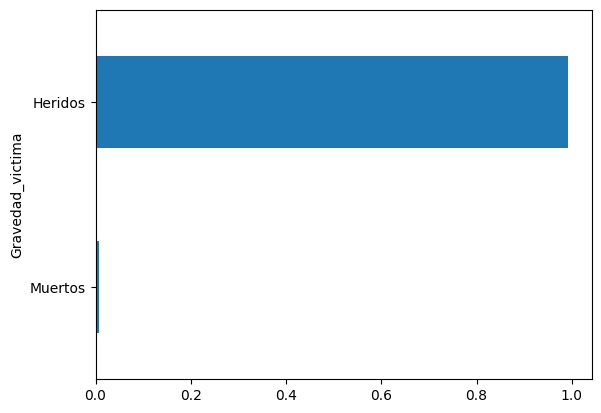

In [486]:
df_accidentes['Gravedad_victima'].value_counts(normalize=True, ascending=True).plot(kind='barh')

<Axes: ylabel='Sexo'>

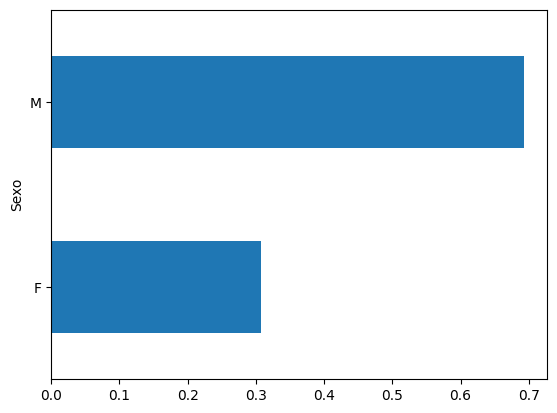

In [487]:
df_accidentes['Sexo'].value_counts(normalize=True, ascending=True).plot(kind='barh')

<Axes: ylabel='Clase_incidente'>

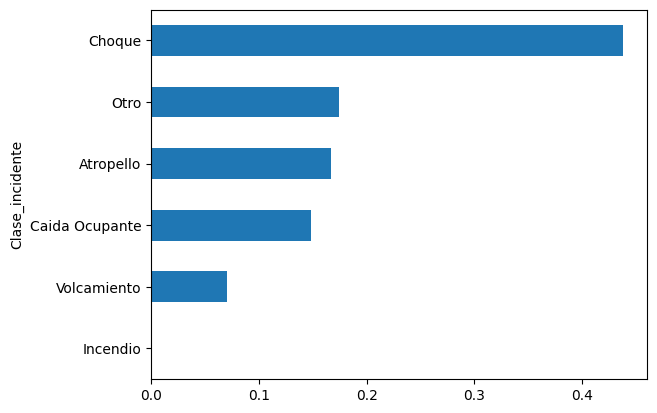

In [488]:
df_accidentes['Clase_incidente'].value_counts(normalize=True, ascending=True).plot(kind='barh')

<Axes: ylabel='Condicion'>

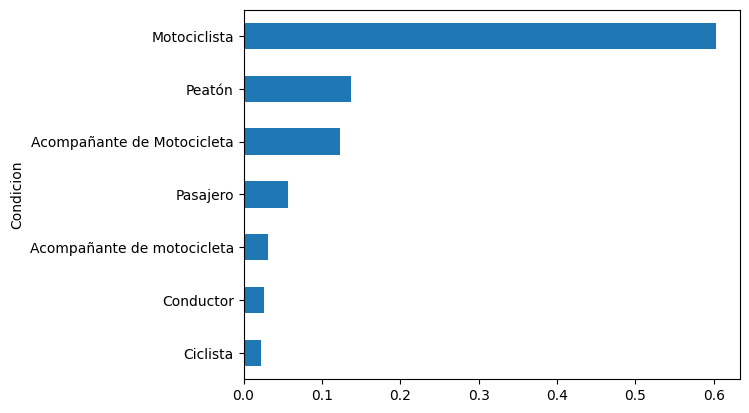

In [489]:
df_accidentes['Condicion'].value_counts(normalize=True, ascending=True).plot(kind='barh')

<Axes: ylabel='Comuna'>

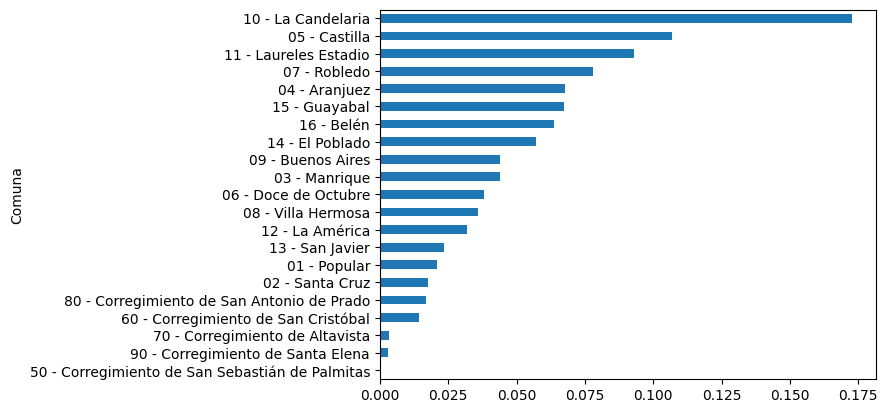

In [490]:
df_accidentes['Comuna'].value_counts(normalize=True, ascending=True).plot(kind='barh')

<Axes: xlabel='Grupo_edad'>

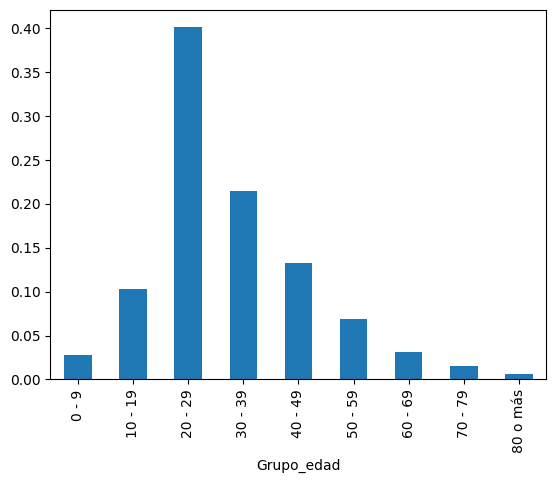

In [491]:
#Variables ordinales

df_accidentes['Grupo_edad'].value_counts(normalize=True, sort = False).plot(kind='bar')


<Axes: xlabel='Mes'>

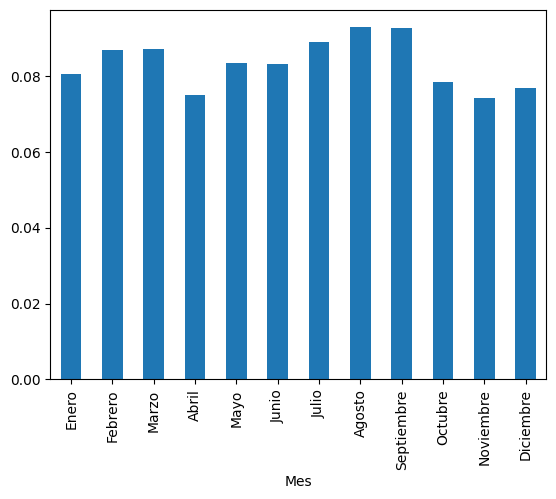

In [492]:
df_accidentes['Mes'].value_counts(normalize=True, sort = False).plot(kind='bar')

<Axes: xlabel='Dia_semana'>

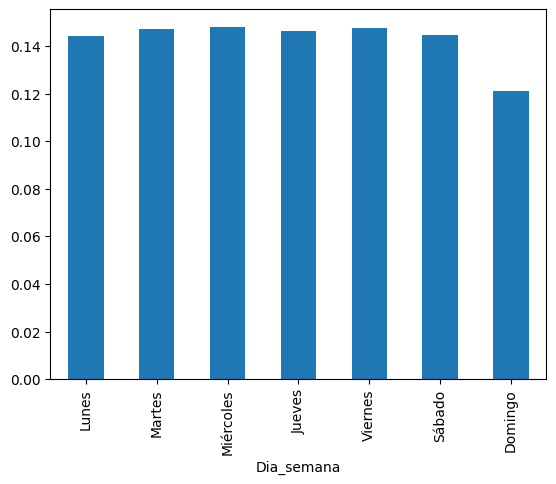

In [493]:
df_accidentes['Dia_semana'].value_counts(normalize=True, sort = False).plot(kind='bar')

<Axes: xlabel='Año'>

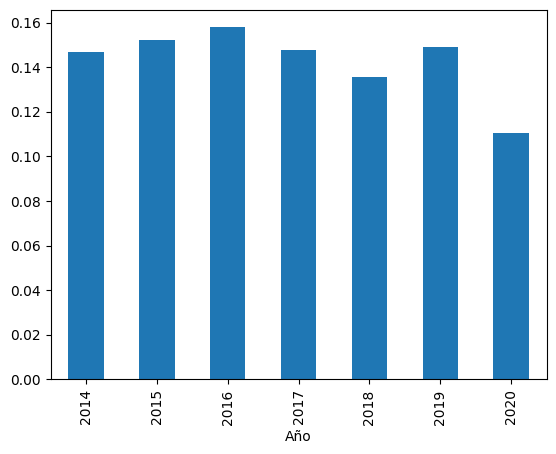

In [494]:
df_accidentes['Año'].value_counts(normalize=True, sort = False).plot(kind='bar')

Para las variables ordinales, haga un gráfico de barras vertical de la tabla de frecuencia acumulada, ordenada de acuerdo al orden de las categorías.

Para las variables ordinales, calcule la mediana, y los quartiles 1, 2 y 3.

Mediana =  20 - 29
Percentiles = Index(['20 - 29', '20 - 29', '40 - 49'], dtype='object')


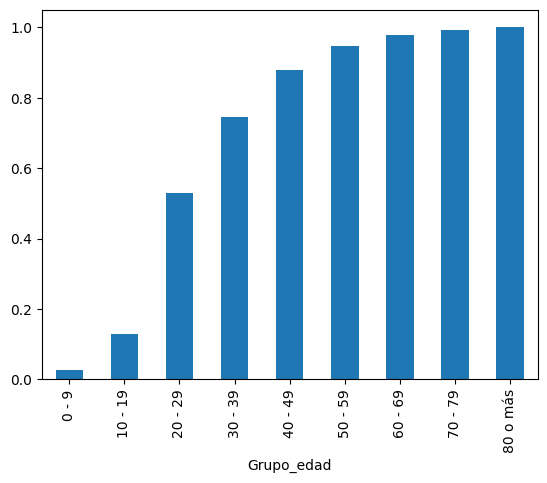

In [495]:
df_accidentes['Grupo_edad'].value_counts(normalize=True, sort=False).cumsum().plot(kind='bar')

print("Mediana = ", df_accidentes['Grupo_edad'].cat.categories[df_accidentes['Grupo_edad'].cat.codes.median().astype(int)] )


print("Percentiles =", df_accidentes['Grupo_edad'].cat.categories[df_accidentes['Grupo_edad'].cat.codes.quantile([0.25, 0.5, 0.75]).astype(int)] )


Mediana =  Julio
Percentiles = Index(['Marzo', 'Julio', 'Septiembre'], dtype='object')


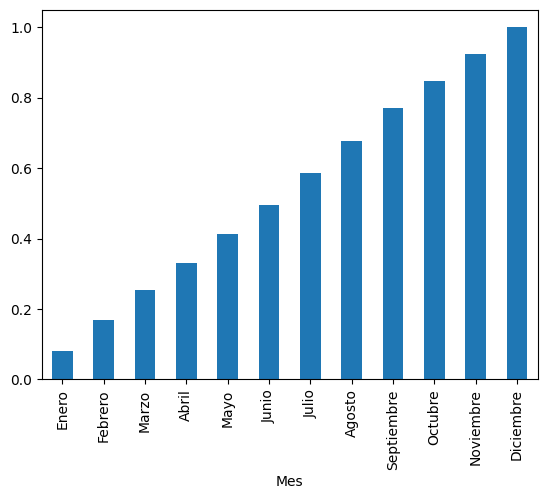

In [496]:
df_accidentes['Mes'].value_counts(normalize=True, sort=False).cumsum().plot(kind='bar')

print("Mediana = ", df_accidentes['Mes'].cat.categories[df_accidentes['Mes'].cat.codes.median().astype(int)] )


print("Percentiles =", df_accidentes['Mes'].cat.categories[df_accidentes['Mes'].cat.codes.quantile([0.25, 0.5, 0.75]).astype(int)] )


Mediana =  Jueves
Percentiles = Index(['Martes', 'Jueves', 'Sábado'], dtype='object')


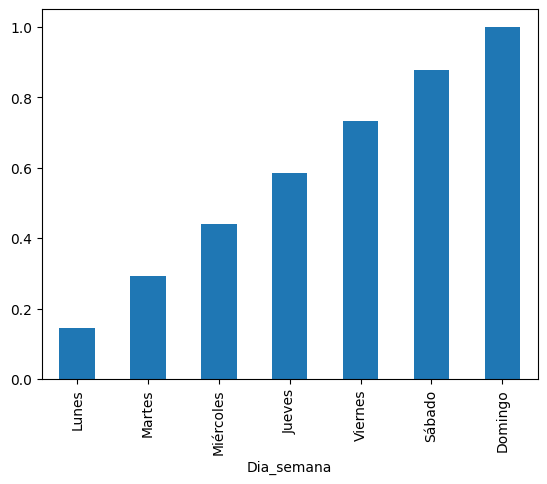

In [497]:
df_accidentes['Dia_semana'].value_counts(normalize=True, sort=False).cumsum().plot(kind='bar')

print("Mediana = ", df_accidentes['Dia_semana'].cat.categories[df_accidentes['Dia_semana'].cat.codes.median().astype(int)] )


print("Percentiles =", df_accidentes['Dia_semana'].cat.categories[df_accidentes['Dia_semana'].cat.codes.quantile([0.25, 0.5, 0.75]).astype(int)] )

Mediana =  2016
Percentiles = Index([2015, 2016, 2018], dtype='int64')


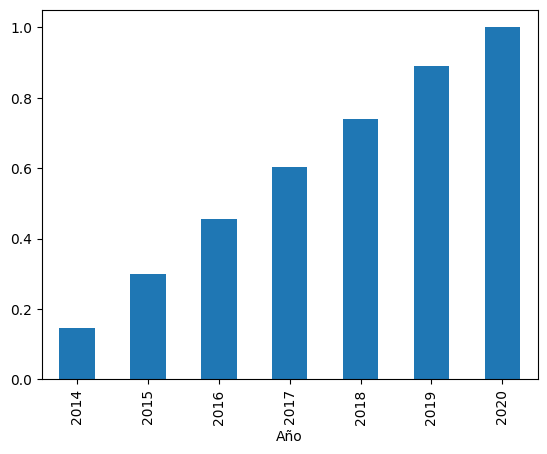

In [498]:
df_accidentes['Año'].value_counts(normalize=True, sort=False).cumsum().plot(kind='bar')

print("Mediana = ", df_accidentes['Año'].cat.categories[df_accidentes['Año'].cat.codes.median().astype(int)] )


print("Percentiles =", df_accidentes['Año'].cat.categories[df_accidentes['Año'].cat.codes.quantile([0.25, 0.5, 0.75]).astype(int)] )
